# Extra: why doesn't the operation swap land? (beyond-paper investigation)

`multilingual.ipynb` is the record; there the operation swap (antonym → synonym,
Fig B3) never crosses under the constrained protocol. Two arms isolate why:

| arm | what varies | tests | formats |
|---|---|---|---|
| 1 | strength → **30×** (coupled ramp; paper 6× on-grid) | "not enough push" | chat + raw |
| 2 | **propagate mode, frozen vs live attention patterns**, paper-faithful config | the paper's QK caveat | chat |

The paper on Haiku: "one crucial interaction (between antonym and large) seems to be
**mediated by changing where attention heads attend** … participating in their **QK
circuits**" — and every constrained intervention runs with attention patterns frozen,
which forbids exactly that channel. Arm 2 therefore runs the identical configuration
in propagate mode twice per language: patterns frozen vs patterns live. Everything
else matches §C of the main notebook (reviewed `antonym (multilingual)` sources at
member positions, `synonym (multilingual)` donors at the operation-word span, 21-point
ladders with the paper endpoint marked, expected token = the model's own synonym
answer); readouts (reviewed `say small` / `say large`) at 6× and the arm endpoint.

In [1]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import multilingual_helper as M
import torch
from build_supernodes import op_word_positions

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_multilingual" / SIZE
OUT.mkdir(parents=True, exist_ok=True)
SN_INPUTS = artifacts_dir() / "supernode_inputs" / SIZE

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
tc = load_transcoder(
    f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16, lazy_decoder=False
).transcoder
N_LAYERS = len(tc)

manifest = json.loads((SN_INPUTS / "manifest.json").read_text())
GRAPH_NAMES = [f"{p}antonym_{lg}" for p in ("", "raw_") for lg in M.LANGS] + [
    "synonym_en",
    "raw_synonym_en",
]
dev = next(model.parameters()).device
graphs, ids, fin = {}, {}, {}
for name in GRAPH_NAMES:
    info = manifest["graphs"][name]
    graphs[name] = json.loads((SN_INPUTS / f"graph_{name}.json").read_text())
    tok_fn = M.tokenize_raw if info["raw"] else M.tokenize
    ids[name] = tok_fn(tokenizer, info["prompt"], dev)
    assert ids[name].shape[1] == info["n_tokens"], name
    fin[name] = info["final_position"]

SN = {
    fmt: M.load_supernodes(f"supernodes/multilingual_{fmt}_{SIZE}.json") for fmt in ("chat", "raw")
}

behavior = {"antonym": {}, "synonym": {}}
raw_behavior = {"antonym": {}, "synonym": {}}
for lg in M.LANGS:
    for key, fn in (("antonym", M.antonym_prompt), ("synonym", M.synonym_prompt)):
        tid, tstr, _ = M.model_answer(model, tokenizer, fn("small", lg))
        behavior[key][lg] = {"token_id": tid, "token": tstr}
    for key, fn in (("antonym", M.raw_antonym_prompt), ("synonym", M.raw_synonym_prompt)):
        tid, tstr, _ = M.model_answer(model, tokenizer, fn("small", lg), raw=True)
        raw_behavior[key][lg] = {"token_id": tid, "token": tstr}
for lg in M.LANGS:
    assert (
        behavior["antonym"][lg]["token_id"]
        == manifest["graphs"][f"antonym_{lg}"]["answer_token_id"]
    )
print(f"Qwen3-{SIZE} on {DEVICE}; swap targets (the model's own synonym answers):")
for lg in M.LANGS:
    print(
        f"  {lg}: chat {behavior['synonym'][lg]['token']!r}, raw {raw_behavior['synonym'][lg]['token']!r}"
    )

[07/12/26 05:10:35] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/12/26 05:10:40] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen3-4b on cuda; swap targets (the model's own synonym answers):
  en: chat 'tiny', raw 'tiny'
  fr: chat 'pet', raw 'pet'
  zh: chat '小', raw '小'


In [2]:
# Shared runner. A config = one job spec builder; every arm is a list of jobs run
# through the same sweep/ladder/readout machinery, differing only in donors, donor
# positions, strengths, and protocol (constrained vs propagate x attention freezing).
all_results, all_readouts = {}, {}
PAPER_S = 6.0  # the paper endpoint (marked on every panel; an exact grid point)
N_STEPS = 21


def run_config(
    arm,
    fmt,
    lg,
    donor_sn,
    donor_positions_of,
    *,
    ext,
    constrained=True,
    freeze_attention=True,
    label_suffix="",
):
    beh = behavior if fmt == "chat" else raw_behavior
    donor_graph = "synonym_en" if fmt == "chat" else "raw_synonym_en"
    rec = f"antonym_{lg}" if fmt == "chat" else f"raw_antonym_{lg}"
    ivs_fn = M.swap_ivs_fn(
        SN[fmt]["antonym (multilingual)"],
        rec,
        fin[rec],
        donor_sn,
        donor_graph,
        donor_positions_of(rec, lg),
        kind="operation",
        strengths=ext,
    )
    expected = beh["synonym"][lg]["token_id"]
    if constrained:
        ell, curve = M.choose_swap_end_layer(model, tc, ids[rec], ivs_fn(ext[1]), expected)
    else:
        ell, curve = None, None
    r = M.supernode_swap_sweep(
        model,
        tc,
        ids[rec],
        ivs_fn,
        tokenizer,
        kind="operation",
        baseline_token=beh["antonym"][lg]["token_id"],
        expected_token=expected,
        patch_end_layer=ell,
        n_steps=N_STEPS,
        strengths=ext,
        freeze_attention=freeze_attention,
    )
    if curve is not None:
        r["l_max"] = curve.end_layers[0]
    key = f"{fmt}_{lg}{label_suffix}"
    all_results.setdefault(arm, {})[key] = r
    i_p = r["strengths"].index(PAPER_S)
    ell_s = (
        f"ell={ell}"
        if ell is not None
        else ("propagate+frozen" if freeze_attention else "propagate+LIVE-attn")
    )
    print(
        f"{arm} {key}: {ell_s} | crossover={r['crossover']} "
        f"p_exp@{PAPER_S:g}x={r['p_expected'][i_p]:.3f} "
        f"p_exp@{ext[1]:g}x={r['p_expected'][-1]:.3f} top@{ext[1]:g}x={r['top_tokens'][-1][:3]}"
    )
    # say-small / say-large readouts at the paper endpoint and the arm endpoint
    ro = {
        "say_small_pct_stored": (SN[fmt]["say small (multilingual)"], donor_graph),
        "say_large_pct_baseline": (SN[fmt]["say large (multilingual)"], None),
    }
    rl = M.readout_layers_above([sn for sn, _ in ro.values()], ell if ell is not None else -1)
    for s in (PAPER_S, ext[1]):
        res = M.run_feature_intervention(
            model,
            tc,
            ids[rec],
            ivs_fn(s),
            n_bos_tokens=M.N_BOS,
            patch_end_layer=ell,
            freeze_attention=freeze_attention,
            readout_layers=rl,
        )
        row = {
            name: M.supernode_readout(
                res, sn, rec, final_pos=fin[rec], ref_graph=rg, patch_end_layer=ell
            )
            for name, (sn, rg) in ro.items()
        }
        all_readouts[f"{arm}_{key}@{s:g}x"] = row
        M.print_readout_row(f"   @{s:g}x", row)
    return r


def span_positions(rec, lg):
    span = sorted(op_word_positions(graphs[rec], M.OP_WORD[lg]))
    assert span, f"operation word not found in {rec}"
    return span


def arm_panel(arm, keys_by_row, fname, title):
    fig, axes = plt.subplots(
        len(keys_by_row), 3, figsize=(12.8, 3.6 * len(keys_by_row)), squeeze=False
    )
    for ri, (row_label, key_fn) in enumerate(keys_by_row):
        beh = raw_behavior if row_label == "raw" else behavior
        token_strs = {
            lg: (beh["antonym"][lg]["token"].strip(), beh["synonym"][lg]["token"].strip())
            for lg in M.LANGS
        }
        M.plot_swap_sweeps(
            {lg: all_results[arm][key_fn(lg)] for lg in M.LANGS},
            tokenizer,
            token_strs,
            title="",
            ax_row=axes[ri],
        )
        for ax in axes[ri]:
            ax.axvline(PAPER_S, color="grey", ls=":", alpha=0.8)
            ax.text(PAPER_S, 1.0, " paper", color="grey", fontsize=7, va="top")
        axes[ri][0].set_ylabel(f"{row_label}\nnext-token probability")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=130, bbox_inches="tight")
    plt.show()

## Arm 1 — more strength: the main configuration to 30×

The v3.1 run reached 15× (source −14×). If the operation swap is like the operand swap
(same recipe, bigger constant — raw-zh there needed 18×), doubling again should show a
crossover; if it is like the language swap (saturates then breaks) or not a handle at
all, it won't.

arm1_strength30 chat_en: ell=15 | crossover=None p_exp@6x=0.000 p_exp@30x=0.000 top@30x=[('medium', 0.715), ('large', 0.16), ('big', 0.097)]
readout    @6x: say_small 35.0% (n=6), say_large 76.9% (n=6)


readout    @30x: say_small 24.3% (n=6), say_large 53.6% (n=6)


arm1_strength30 chat_fr: ell=17 | crossover=None p_exp@6x=0.000 p_exp@30x=0.001 top@30x=[('grand', 0.96), ('Grand', 0.029), ('gr', 0.008)]
readout    @6x: say_small 25.5% (n=6), say_large 88.6% (n=6)


readout    @30x: say_small 25.0% (n=6), say_large 70.4% (n=6)


arm1_strength30 chat_zh: ell=13 | crossover=None p_exp@6x=0.000 p_exp@30x=0.163 top@30x=[('大', 0.73), ('小', 0.163), ('"', 0.099)]
readout    @6x: say_small 16.3% (n=6), say_large 35.8% (n=6)


...

readout    @30x: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned)


arm1_strength30 raw_fr: ell=35 | crossover=None p_exp@6x=0.000 p_exp@30x=0.000 top@30x=[('grand', 0.989), ('g', 0.008), ('gr', 0.002)]
readout    @6x: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned)


readout    @30x: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned)


arm1_strength30 raw_zh: ell=34 | crossover=None p_exp@6x=0.002 p_exp@30x=0.005 top@30x=[('大', 0.987), ('小', 0.005), ('____', 0.002)]
readout    @6x: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned)


readout    @30x: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned)


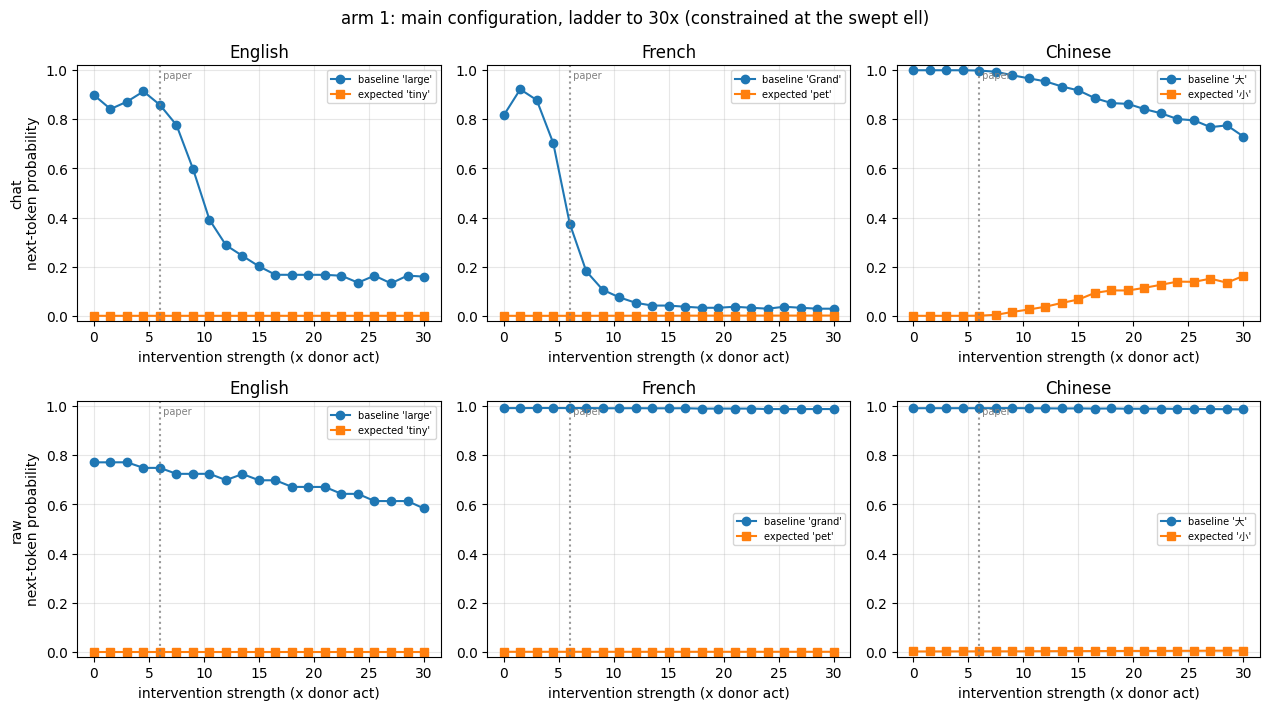

In [3]:
for fmt in ("chat", "raw"):
    for lg in M.LANGS:
        run_config(
            "arm1_strength30",
            fmt,
            lg,
            SN[fmt]["synonym (multilingual)"],
            span_positions,
            ext=(-29.0, 30.0),
        )
arm_panel(
    "arm1_strength30",
    [("chat", lambda lg: f"chat_{lg}"), ("raw", lambda lg: f"raw_{lg}")],
    "extra_operation_sweep_arm1.png",
    "arm 1: main configuration, ladder to 30x (constrained at the swept ell)",
)

## Arm 2 — the paper's QK caveat: propagate mode, frozen vs live attention patterns

The paper: the antonym→large interaction on Haiku "seems to be mediated by changing
where attention heads attend … participating in their QK circuits", and is "invisible"
to the frozen-attention method. Every constrained run freezes patterns by construction
(circuit-tracer's coupling), so if Qwen3's antonym→synonym channel is QK-mediated, NO
constrained configuration can land it at any strength. This arm runs the paper-faithful configuration in **propagate mode**
(no pinning) twice per language: patterns frozen vs patterns **live** (the model may
re-attend). A flip that appears only with live patterns is direct evidence for the QK
story.

arm2_qk_probe chat_en_frozen: propagate+frozen | crossover=None p_exp@6x=0.000 p_exp@15x=0.000 top@15x=[('large', 0.741), ('big', 0.212), ('small', 0.029)]
readout    @6x: say_small 50.9% (n=6), say_large 86.5% (n=6)


readout    @15x: say_small 73.2% (n=6), say_large 71.0% (n=6)


arm2_qk_probe chat_en_live: propagate+LIVE-attn | crossover=6.75 p_exp@6x=0.000 p_exp@15x=0.186 top@15x=[('little', 0.735), ('tiny', 0.186), ('small', 0.077)]


readout    @6x: say_small 107.1% (n=6), say_large 57.1% (n=6)


readout    @15x: say_small 124.0% (n=6), say_large 59.8% (n=6)


...

arm2_qk_probe chat_zh_frozen: propagate+frozen | crossover=None p_exp@6x=0.003 p_exp@15x=0.146 top@15x=[('大', 0.653), ('"', 0.187), ('小', 0.146)]
readout    @6x: say_small 12.7% (n=6), say_large 43.6% (n=6)


readout    @15x: say_small 5.8% (n=6), say_large 20.0% (n=6)


arm2_qk_probe chat_zh_live: propagate+LIVE-attn | crossover=8.25 p_exp@6x=0.000 p_exp@15x=0.005 top@15x=[('大', 0.994), ('小', 0.005), ('“', 0.001)]


readout    @6x: say_small 17.3% (n=6), say_large 66.9% (n=6)


readout    @15x: say_small 38.0% (n=6), say_large 49.7% (n=6)


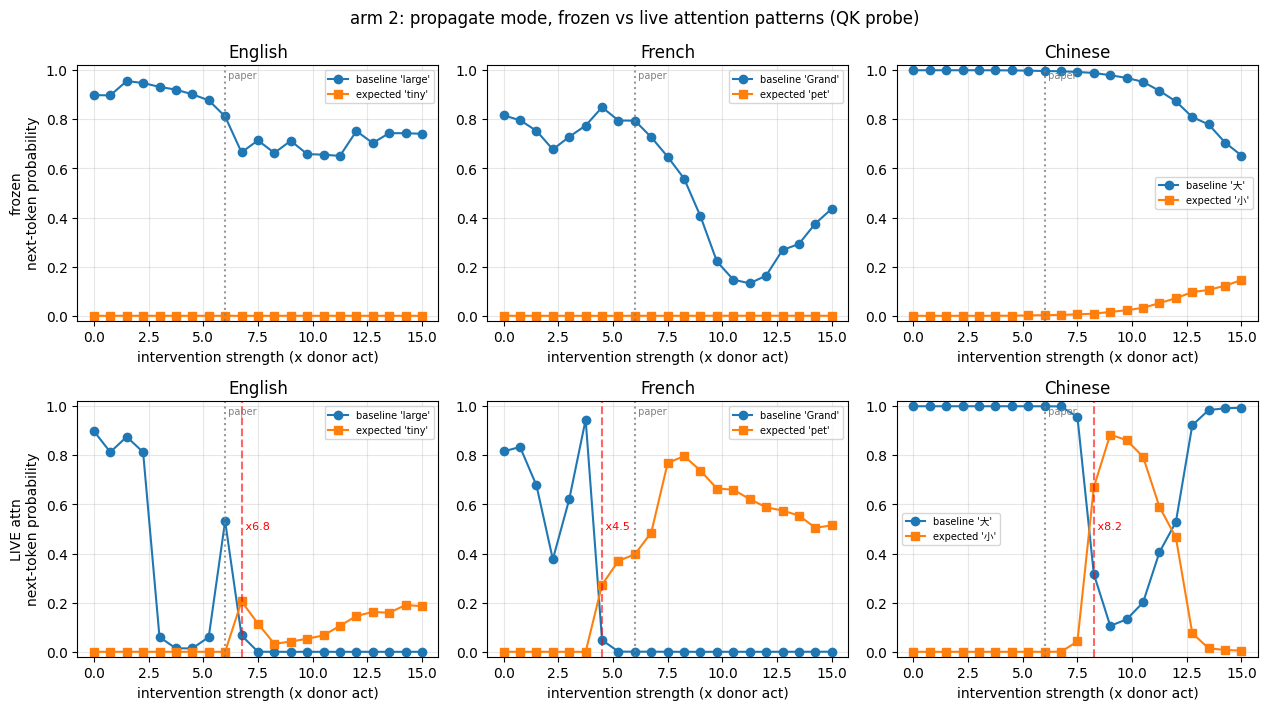

In [4]:
for lg in M.LANGS:
    run_config(
        "arm2_qk_probe",
        "chat",
        lg,
        SN["chat"]["synonym (multilingual)"],
        span_positions,
        ext=(-14.0, 15.0),
        constrained=False,
        freeze_attention=True,
        label_suffix="_frozen",
    )
    run_config(
        "arm2_qk_probe",
        "chat",
        lg,
        SN["chat"]["synonym (multilingual)"],
        span_positions,
        ext=(-14.0, 15.0),
        constrained=False,
        freeze_attention=False,
        label_suffix="_live",
    )
arm_panel(
    "arm2_qk_probe",
    [
        ("frozen", lambda lg: f"chat_{lg}_frozen"),
        ("LIVE attn", lambda lg: f"chat_{lg}_live"),
    ],
    "extra_operation_sweep_arm2.png",
    "arm 2: propagate mode, frozen vs live attention patterns (QK probe)",
)

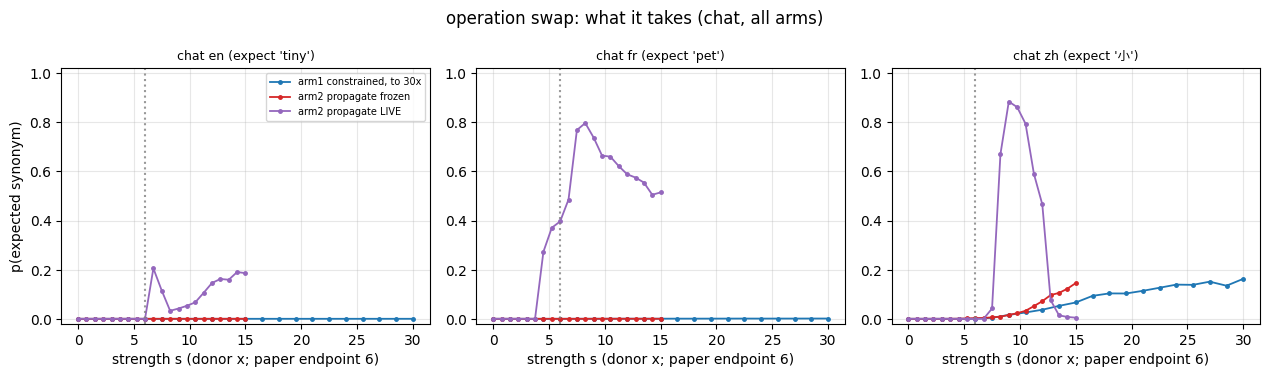

verdict lines:
  arm1_strength30        chat_en          crossover=None p_exp@end=0.000 top@end=('medium', 0.715)
  arm1_strength30        chat_fr          crossover=None p_exp@end=0.001 top@end=('grand', 0.96)
  arm1_strength30        chat_zh          crossover=None p_exp@end=0.163 top@end=('大', 0.73)
  arm1_strength30        raw_en           crossover=None p_exp@end=0.000 top@end=('large', 0.584)
  arm1_strength30        raw_fr           crossover=None p_exp@end=0.000 top@end=('grand', 0.989)
  arm1_strength30        raw_zh           crossover=None p_exp@end=0.005 top@end=('大', 0.987)
  arm2_qk_probe          chat_en_frozen   crossover=None p_exp@end=0.000 top@end=('large', 0.741)
  arm2_qk_probe          chat_en_live     crossover=6.75 p_exp@end=0.186 top@end=('little', 0.735)
  arm2_qk_probe          chat_fr_frozen   crossover=None p_exp@end=0.000 top@end=('grand', 0.56)
  arm2_qk_probe          chat_fr_live     crossover=4.5 p_exp@end=0.515 top@end=('pet', 0.515)
  arm2_qk_probe  

In [5]:
# Cross-arm comparison (chat): p(expected synonym) vs strength, arms overlaid.
fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.8), squeeze=False)
STYLE = {
    "arm1_strength30": ("C0", "arm1 constrained, to 30x", lambda lg: f"chat_{lg}"),
    "arm2_qk_probe_frozen": ("C3", "arm2 propagate frozen", lambda lg: f"chat_{lg}_frozen"),
    "arm2_qk_probe_live": ("C4", "arm2 propagate LIVE", lambda lg: f"chat_{lg}_live"),
}
for ci, lg in enumerate(M.LANGS):
    ax = axes[0][ci]
    for arm_key, (c, lab, key_fn) in STYLE.items():
        arm = "arm2_qk_probe" if arm_key.startswith("arm2_qk") else arm_key
        r = all_results[arm].get(key_fn(lg))
        if r is None:
            continue
        ax.plot(r["strengths"], r["p_expected"], "o-", ms=2.5, lw=1.3, color=c, label=lab)
    ax.axvline(PAPER_S, color="grey", ls=":", alpha=0.8)
    ax.set_title(f"chat {lg} (expect {behavior['synonym'][lg]['token'].strip()!r})", fontsize=9)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.set_xlabel("strength s (donor x; paper endpoint 6)")
    if ci == 0:
        ax.legend(fontsize=7)
        ax.set_ylabel("p(expected synonym)")
fig.suptitle("operation swap: what it takes (chat, all arms)")
fig.tight_layout()
fig.savefig(OUT / "extra_operation_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

(OUT / "extra_operation_results.json").write_text(
    json.dumps(all_results, indent=1, ensure_ascii=False, default=str)
)
(OUT / "extra_operation_readouts.json").write_text(
    json.dumps(all_readouts, indent=1, ensure_ascii=False, default=str)
)
print("verdict lines:")
for arm, res in all_results.items():
    for key, r in res.items():
        print(
            f"  {arm:22s} {key:16s} crossover={r['crossover']} "
            f"p_exp@end={r['p_expected'][-1]:.3f} top@end={r['top_tokens'][-1][0]}"
        )

## Summary

**The operation swap fails for a protocol reason, not strength: its channel is
attention-pattern-mediated, and frozen patterns forbid it.**

| arm | en | fr | zh |
|---|---|---|---|
| 1 constrained, → 30× | `medium` @ .72 — never the synonym | grand holds @ .96 | 大 holds @ .73 (小 @ .16) |
| 2 propagate, patterns **frozen** | flat 0 | flat 0 | flat 0 (大 @ .65) |
| 2 propagate, patterns **LIVE** | **crosses ×6.75 — `little` @ 0.735**, the paper's exact EN token | **crosses ×4.5 — `pet` @ 0.515**, the model's own synonym | crosses ×8.25 mid-ladder, reverts by 15× (大 @ .99) |

1. **Strength is ruled out (arm 1):** at 5× the paper's endpoint the paper-faithful
   configuration still lands on adjacent semantics, never the synonym.
2. **The QK probe is decisive (arm 2):** the identical configuration — same reviewed
   sources, same donors, same strengths — lands language-appropriate synonyms when
   attention patterns may re-form, and does nothing when they are frozen. This is the
   paper's own Haiku caveat ("one crucial interaction … seems to be mediated by
   changing where attention heads attend … participating in their QK circuits")
   realized on Qwen3: constrained patching always freezes patterns, so **no
   constrained configuration can land this swap at any strength or selection** — the
   main notebook's operation nulls are protocol-assumption meets QK-mediated circuit.
3. Together with the main notebook: **operand** = MLP-pathway (works frozen, needs
   strength), **language** = direct-path (works at ℓ=35, saturates), **operation** =
   QK-mediated (needs live attention).

**Caveats.** Arm 2 is propagate-mode by necessity ("constrained with live attention"
does not exist in the protocol); its frozen twin is the controlled comparison. zh's
live-attention flip is non-monotone (crosses mid-ladder, reverts at 15×).
`multilingual.ipynb` remains the paper-protocol record.